# OSA Walkthrough

This notebook is intended as a practical introduction for users who have never worked with the Optical Spectrum Analyzer (OSA) or the `osa_simple.py` library.

Its goal is to explain, step by step, the basic measurement workflow, from establishing a connection with the instrument to acquiring and saving an optical spectrum.

By the end of this guide, you will be able to:

- Connect to the OSA from Python.
- Configure the basic measurement parameters.
- Execute a sweep.
- Retrieve the acquired spectrum.
- Visualize and save the measurement data.

No prior knowledge of SCPI, PyVISA, or the internal implementation of osa_simple.py is required. This guide focuses on the practical use of the library and introduces only the concepts needed to begin performing optical spectrum measurements.

---

First choose one of the following imports

**Option 1 (recommended): Import the installed version from the pic_upv package.**

In [ ]:
from pic_upv.osa_simple import YeniOSA

**Option 2: Import this version if you are editing the local osa_simple.py file and want to test those changes.**

In [ ]:
from osa_simple import YeniOSA

---
Step 1: Import the necessary libraries.

In [ ]:
import matplotlib.pyplot as plt
import time

Step 2: Connect to the Optical Spectrum Analyzer (OSA). First, create an instance of the OSA driver. Then, establish the
communication with the instrument using the `connect()` method.

In [17]:
osa = YeniOSA()
osa.connect()

Step 3: Configure the sweep parameters.

Before running a measurement, we need to define the basic sweep parameters. The most important ones are:

- **Center wavelength (`CENTER`)**: The central wavelength of the sweep in nanometers.
- **Span (`SPAN`)**: The total wavelength range to sweep, also in nanometers.
- **Resolution (`RESOLUTION`)**: The resolution bandwidth of the OSA. A smaller value gives higher spectral detail but takes longer to sweep.
- **Sensitivity (`SENSITIVITY`)**: The sensitivity level of the detector, typically in dBm. This sets the noise floor of the measurement.

These parameters are passed to the `setup_sweep()` method, which sends the appropriate SCPI commands to the OSA.

In [ ]:
CENTER = 1550
SPAN = 90
RESOLUTION = 0.2
SENSITIVITY = -70

osa.setup_sweep(
    center_nm=CENTER,
    span_nm=SPAN,
    resolution_nm=RESOLUTION,
    sensitivity_dbm=SENSITIVITY,
)

Step 4: Run the sweep and retrieve the trace.

Now, we initiate the sweep, wait for it to complete, and then read the trace data from the instrument. The `run_sweep()` method triggers the measurement and monitors its progress. Once finished, the `get_trace()` method retrieves the data.

> **Note:** The `VI_ERROR_TMO (-1073807339): Timeout expired before operation completed` error may appear if the communication timeout expires before the OSA completes the requested operation. In this case, the operation is reading the trace metadata of the spectrum that was just acquired.
>
> Although the sweep may have reached 100% completion, the OSA may require additional time to process the acquired data and make it available for reading.
>
> For this reason, the `get_trace()` method provides two parameters to control the metadata polling process:
>
> - **`metadata_poll_s`**: Defines the time interval, in seconds, between consecutive attempts to check whether the trace metadata is available.
> - **`metadata_retries`**: Defines the maximum number of attempts made to check whether the trace metadata is available.
>
> Increasing these values can be useful when the OSA requires additional processing time before the trace can be retrieved.

In [ ]:
osa.run_sweep(
trace=1,
averages=1,
progress_poll_s=0.5,
start_delay_s=2.0,
)

trace = osa.get_trace(
    trace=1,
    metadata_poll_s=0.2,
    metadata_retries=5,
)

Step 5: Plot the acquired trace.

Once the trace has been retrieved from the OSA, we can visualize the measured optical spectrum. The wavelength data is used as the x-axis, while the measured optical power is plotted on the y-axis.

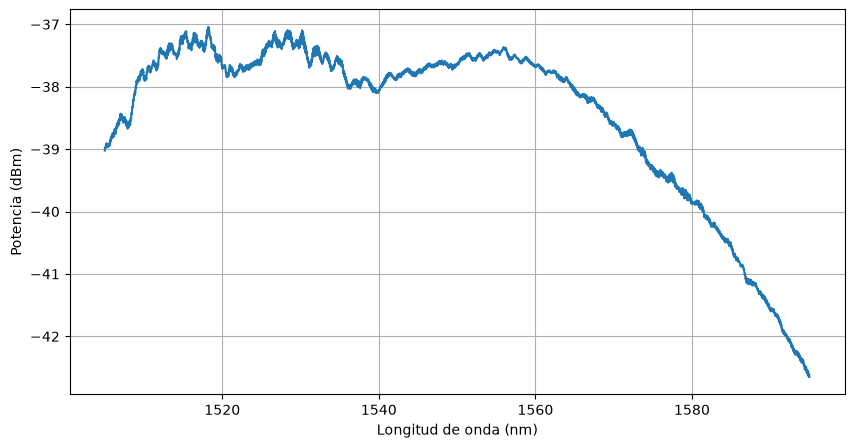

In [10]:
plt.figure(figsize=(10,5))

plt.plot(
    trace.wavelength_nm,
    trace.power_dbm
)

plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Potencia (dBm)")
plt.grid(True)

Step 6: Automated multiple sweeps with error handling

In real laboratory environments, it's often necessary to perform multiple measurements to ensure reproducibility or to capture data under different conditions. This step demonstrates how to:

- **Automate a series of sweeps** using a loop
- **Handle potential errors**  with try-except blocks
- **Save each measurement** with a unique timestamped filename
- **Organize data** in a dedicated folder (`data_OSA/`)

In [ ]:
from datetime import datetime

N = 2

for i in range(N):

    print(f"\n========== Sweep {i+1}/{N} ==========")

    try:

        osa.run_sweep(
            trace=1,
            averages=1,
            progress_poll_s=0.5,
            start_delay_s=2.0,
        )

        trace = osa.get_trace(
            trace=1,
            metadata_poll_s=0.2,
            metadata_retries=5,
        )

        filename = (
            f"data_OSA/test_{i+1}_"
            f"{datetime.now():%Y%m%d_%H%M%S}.txt"
        )

        trace.save_txt(filename)

        print(f"Saved: {filename}")

    except Exception as e:

        print(f"Sweep {i+1} failed")
        print(e)

Step 7: Disconnection

After completing all measurements, it's essential to properly close the connection to the OSA

In [21]:
osa.close()